# Chương 5: Ứng dụng thực tế  
## Phân tích giỏ hàng - Market Basket Analysis

Notebook này minh họa ứng dụng thuật toán khai phá **frequent itemsets** đã cài đặt trong project để phân tích dữ liệu giỏ hàng từ file `groceries.txt`.

**Mục tiêu chính:**

1. Đọc và tiền xử lý dữ liệu bán lẻ thành dạng transaction.
2. Tìm các tập sản phẩm xuất hiện thường xuyên.
3. Sinh luật kết hợp dạng `X ⇒ Y`.
4. Lọc luật theo `support ≥ minsup` và `confidence ≥ minconf`.
5. Trình bày **top-10 luật theo lift** và giải thích ý nghĩa kinh doanh.


## 1. Cơ sở lý thuyết ngắn gọn

**Market Basket Analysis** là kỹ thuật phân tích các giao dịch mua hàng để phát hiện những sản phẩm thường được mua cùng nhau.

Với một luật kết hợp:

```text
X ⇒ Y
```

các chỉ số được hiểu như sau:

- **Support**: tỷ lệ giao dịch chứa đồng thời cả `X` và `Y`.
- **Confidence**: trong các giao dịch có `X`, tỷ lệ giao dịch cũng có `Y`.
- **Lift**: mức độ `X` và `Y` xuất hiện cùng nhau nhiều hơn so với kỳ vọng ngẫu nhiên.

Nếu `lift > 1`, hai nhóm sản phẩm có quan hệ mua kèm tích cực.


## 2. Khởi tạo môi trường và đường dẫn

Notebook nằm trong thư mục `notebooks/`, vì vậy đường dẫn dữ liệu mặc định là:

```text
../data/application/groceries.txt
```

Cell dưới đây cũng tự xác định `project_root` để có thể gọi source code trong project. Các biểu đồ trong notebook được lưu vào:

```text
../docs/figures/
```

Việc lưu hình giúp có thể tái sử dụng trực tiếp trong báo cáo mà không cần chụp lại từ notebook.


In [45]:
import random
import numpy as np
from pathlib import Path
from collections import Counter
from itertools import combinations
import contextlib
import io
import math
import os
import re
import shutil
import subprocess
import sys
import tempfile
import time

# Reproducibility – best practice dù Apriori là deterministic
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Tránh lỗi optional dependency của pandas trong một số môi trường local.
for optional_module in ("pyarrow", "bottleneck", "numexpr"):
    sys.modules.setdefault(optional_module, None)

with contextlib.redirect_stderr(io.StringIO()):
    import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.precision", 4)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name.lower() == "notebooks" else NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / "data" / "application" / "groceries.txt"
FIGURES_DIR = PROJECT_ROOT / "docs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename):
    """Lưu biểu đồ vào docs/figures để dùng lại trong báo cáo."""
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    print(f"Đã lưu hình: {output_path.relative_to(PROJECT_ROOT)}")


print("Notebook dir:", NOTEBOOK_DIR)
print("Project root:", PROJECT_ROOT)
print("Data path   :", DATA_PATH)
print("Figures dir :", FIGURES_DIR)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy file dữ liệu tại: {DATA_PATH}. "
        "Hãy kiểm tra notebook có nằm trong thư mục notebooks/ không, "
        "và file groceries.txt có nằm trong data/application/ không."
    )


Notebook dir: y:\Python\PrePost\notebooks
Project root: y:\Python\PrePost
Data path   : y:\Python\PrePost\data\application\groceries.txt
Figures dir : y:\Python\PrePost\docs\figures


## 3. Đọc dữ liệu thô

Dữ liệu `groceries.txt` thường có dạng mỗi dòng là một giao dịch, các item cách nhau bằng dấu phẩy. Tuy nhiên, cell dưới đây vẫn hiển thị mẫu dữ liệu để kiểm tra trước khi xử lý.


In [46]:
raw_lines = DATA_PATH.read_text(encoding="utf-8", errors="replace").splitlines()
raw_lines = [line.strip() for line in raw_lines if line.strip()]

print(f"Số dòng không rỗng: {len(raw_lines):,}")
display(pd.DataFrame({"raw_line": raw_lines[:10]}))


Số dòng không rỗng: 9,835


,raw_line
0,"citrus fruit,semi-finished bread,margarine,ready soups"
1,"tropical fruit,yogurt,coffee"
2,whole milk
3,"pip fruit,yogurt,cream cheese ,meat spreads"
4,"other vegetables,whole milk,condensed milk,long life bakery product"
5,"whole milk,butter,yogurt,rice,abrasive cleaner"
6,rolls/buns
7,"other vegetables,UHT-milk,rolls/buns,bottled beer,liquor (appetizer)"
8,pot plants
9,"whole milk,cereals"


## 4. Tiền xử lý thành transaction

Yêu cầu đầu ra của bước này là biến `transactions`:

```python
transactions = [
    ["item1", "item2", ...],
    ...
]
```

Notebook tự nhận diện định dạng phổ biến:

- Dòng có dấu phẩy: tách item theo dấu phẩy.
- Dòng có tab: tách theo tab.
- Dòng chỉ có khoảng trắng: tách theo khoảng trắng.
- Nếu một dòng có dạng `id,item`, notebook gom các item theo mã giao dịch.


In [47]:
def normalize_item(item):
    """Chuẩn hóa tên item để tránh trùng do khoảng trắng hoặc khác chữ hoa/thường."""
    item = str(item).strip()
    item = re.sub(r"\s+", " ", item)
    return item.lower()


def parse_transactions(lines):
    """Trả về transactions và mô tả định dạng phát hiện."""
    non_empty = [line.strip() for line in lines if line.strip()]
    if not non_empty:
        return [], "File rỗng"

    sample = non_empty[: min(50, len(non_empty))]
    comma_counts = [line.count(",") for line in sample]
    tab_counts = [line.count("\t") for line in sample]

    # Nếu đa số dòng có đúng 1 dấu phẩy, có thể là dạng id,item.
    if sum(c == 1 for c in comma_counts) / len(sample) >= 0.8:
        pairs = []
        for line in non_empty:
            left, right = line.split(",", 1)
            left, right = left.strip(), normalize_item(right)
            if left and right:
                pairs.append((left, right))

        # Nếu cột trái lặp lại nhiều lần thì coi là transaction_id.
        left_values = [p[0] for p in pairs]
        repeated_left = len(set(left_values)) < len(left_values) * 0.8

        if repeated_left:
            grouped = {}
            for tid, item in pairs:
                grouped.setdefault(tid, [])
                if item not in grouped[tid]:
                    grouped[tid].append(item)
            return list(grouped.values()), "Bảng 2 cột transaction_id,item"

    comma_ratio = sum("," in line for line in non_empty) / len(non_empty)
    tab_ratio = sum("\t" in line for line in non_empty) / len(non_empty)

    if comma_ratio >= 0.5:
        detected_format = "Mỗi dòng là một transaction, item phân tách bằng dấu phẩy"
        parsed = [[normalize_item(item) for item in line.split(",")] for line in non_empty]
    elif tab_ratio >= 0.5:
        detected_format = "Mỗi dòng là một transaction, item phân tách bằng tab"
        parsed = [[normalize_item(item) for item in line.split("\t")] for line in non_empty]
    else:
        detected_format = "Mỗi dòng là một transaction, item phân tách bằng khoảng trắng"
        parsed = [[normalize_item(item) for item in re.split(r"\s+", line)] for line in non_empty]

    cleaned = []
    for row in parsed:
        items = []
        seen = set()
        for item in row:
            if item and item not in seen:
                items.append(item)
                seen.add(item)
        if items:
            cleaned.append(items)

    return cleaned, detected_format


transactions, detected_format = parse_transactions(raw_lines)

n_transactions = len(transactions)
unique_items = sorted({item for transaction in transactions for item in transaction})
item_counter = Counter(item for transaction in transactions for item in transaction)
basket_sizes = [len(transaction) for transaction in transactions]

print("Định dạng phát hiện:", detected_format)
print(f"Số giao dịch sau xử lý: {n_transactions:,}")
print(f"Số item khác nhau: {len(unique_items):,}")
print(f"Độ dài giỏ hàng trung bình: {sum(basket_sizes) / max(n_transactions, 1):.2f} item")
print(f"Độ dài giỏ hàng nhỏ nhất/lớn nhất: {min(basket_sizes)} / {max(basket_sizes)}")

display(pd.DataFrame({"transaction": transactions[:10]}))


Định dạng phát hiện: Mỗi dòng là một transaction, item phân tách bằng dấu phẩy
Số giao dịch sau xử lý: 9,835
Số item khác nhau: 169
Độ dài giỏ hàng trung bình: 4.41 item
Độ dài giỏ hàng nhỏ nhất/lớn nhất: 1 / 32


,transaction
0,"[citrus fruit, semi-finished bread, margarine, ready soups]"
1,"[tropical fruit, yogurt, coffee]"
2,[whole milk]
3,"[pip fruit, yogurt, cream cheese, meat spreads]"
4,"[other vegetables, whole milk, condensed milk, long life bakery product]"
5,"[whole milk, butter, yogurt, rice, abrasive cleaner]"
6,[rolls/buns]
7,"[other vegetables, uht-milk, rolls/buns, bottled beer, liquor (appetizer)]"
8,[pot plants]
9,"[whole milk, cereals]"


## 5. Khám phá nhanh dữ liệu

Phần này giúp báo cáo có thêm cơ sở thực tế trước khi chạy thuật toán: item nào phổ biến nhất, phân bố kích thước giỏ hàng ra sao.


,item,count,support
0,whole milk,2513,0.2555
1,other vegetables,1903,0.1935
2,rolls/buns,1809,0.1839
3,soda,1715,0.1744
4,yogurt,1372,0.1395
5,bottled water,1087,0.1105
6,root vegetables,1072,0.1090
7,tropical fruit,1032,0.1049
8,shopping bags,969,0.0985
9,sausage,924,0.0940


Đã lưu hình: docs\figures\mba_top_items.png


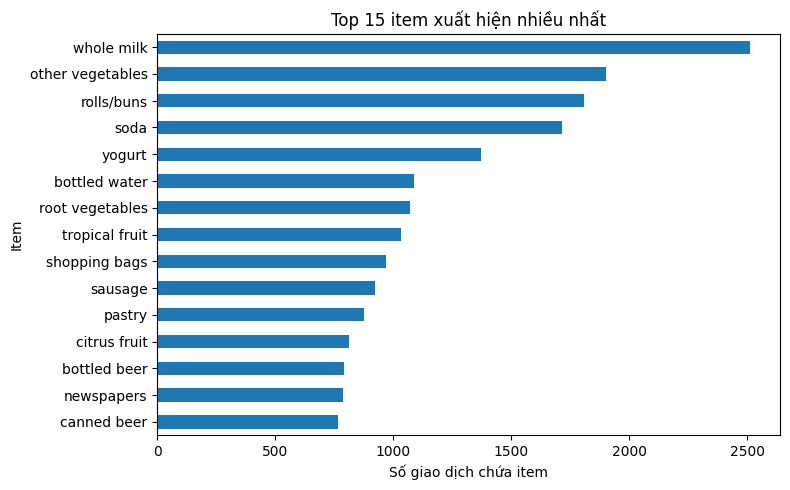

In [48]:
top_items_df = (
    pd.DataFrame(item_counter.most_common(15), columns=["item", "count"])
    .assign(support=lambda df: df["count"] / n_transactions)
)

display(top_items_df)

ax = top_items_df.sort_values("count").plot.barh(x="item", y="count", legend=False, figsize=(8, 5))
ax.set_title("Top 15 item xuất hiện nhiều nhất")
ax.set_xlabel("Số giao dịch chứa item")
ax.set_ylabel("Item")
plt.tight_layout()
save_figure(ax.get_figure(), "mba_top_items.png")
plt.show()


**Nhận xét:** Các item phổ biến nhất như `whole milk`, `other vegetables`, `rolls/buns` và `soda` có support cao hơn hẳn phần còn lại. Đây là các sản phẩm nền tảng, phù hợp để làm điểm neo khi phân tích mua kèm hoặc thiết kế gợi ý sản phẩm.

Đã lưu hình: docs\figures\mba_cooccurrence_top15.png


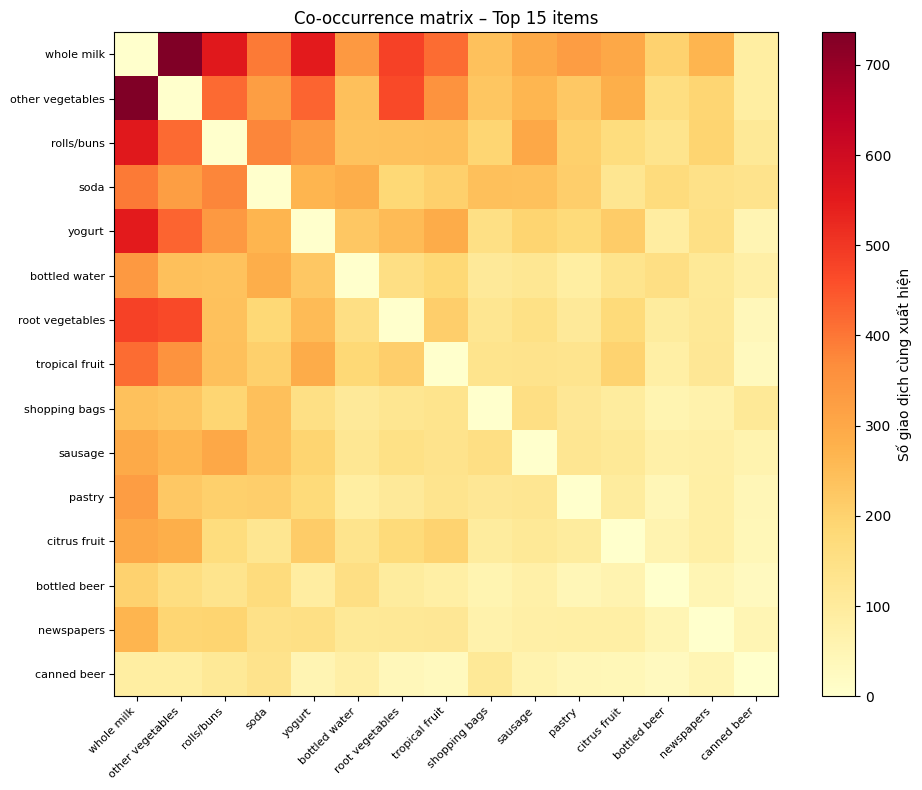

In [49]:
# Co-occurrence matrix của top-15 items
TOP_N = 15
top_item_names = [row["item"] for _, row in top_items_df.iterrows()]

cooc = np.zeros((TOP_N, TOP_N), dtype=int)
for transaction in transactions:
    transaction_set = set(transaction)
    present = [i for i, name in enumerate(top_item_names) if name in transaction_set]
    for a, b in combinations(present, 2):
        cooc[a][b] += 1
        cooc[b][a] += 1

cooc_df = pd.DataFrame(cooc, index=top_item_names, columns=top_item_names)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cooc_df.values, cmap="YlOrRd")
ax.set_xticks(range(TOP_N)); ax.set_xticklabels(top_item_names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(TOP_N)); ax.set_yticklabels(top_item_names, fontsize=8)
plt.colorbar(im, ax=ax, label="Số giao dịch cùng xuất hiện")
ax.set_title("Co-occurrence matrix – Top 15 items")
plt.tight_layout()
save_figure(fig, "mba_cooccurrence_top15.png")
plt.show()


**Nhận xét:** Ma trận đồng xuất hiện cho thấy một số nhóm hàng thường cùng xuất hiện trong cùng giỏ hàng, đặc biệt quanh các sản phẩm thực phẩm thiết yếu. Biểu đồ này giúp kiểm tra trực quan trước khi sinh luật: ô càng đậm thì cặp sản phẩm càng có nhiều giao dịch chung, nhưng vẫn cần dùng thêm `confidence` và `lift` để đánh giá quan hệ có thật sự đáng chú ý hay chỉ do sản phẩm quá phổ biến.

,basket_size
count,9835.0000
mean,4.4095
std,3.5894
min,1.0000
25%,2.0000
50%,3.0000
75%,6.0000
max,32.0000


Đã lưu hình: docs\figures\mba_basket_size_distribution.png


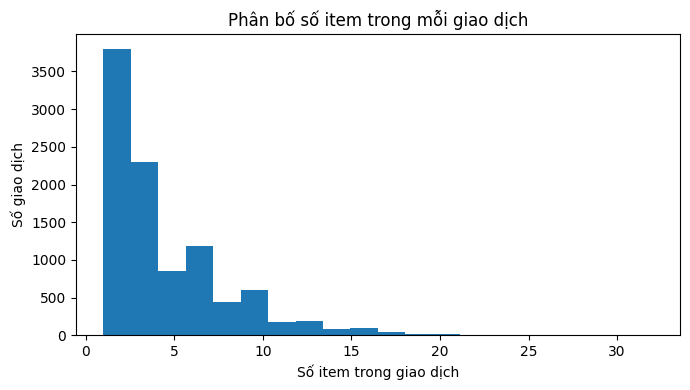

In [50]:
basket_df = pd.DataFrame({"basket_size": basket_sizes})
display(basket_df["basket_size"].describe().to_frame())

ax = basket_df["basket_size"].plot.hist(bins=20, figsize=(7, 4))
ax.set_title("Phân bố số item trong mỗi giao dịch")
ax.set_xlabel("Số item trong giao dịch")
ax.set_ylabel("Số giao dịch")
plt.tight_layout()
save_figure(ax.get_figure(), "mba_basket_size_distribution.png")
plt.show()


**Nhận xét:** Phần lớn giao dịch có số lượng item không quá lớn, vì vậy các luật gồm 1-2 sản phẩm ở vế trái thường dễ diễn giải và dễ áp dụng hơn trong kinh doanh. Những giỏ hàng rất dài vẫn hữu ích, nhưng nếu chỉ dựa vào chúng thì luật có thể trở nên hiếm và khó triển khai đại trà.

## 6. Mã hóa transaction

Để thuận tiện cho thuật toán PrePost/Apriori, mỗi item được ánh xạ sang một số nguyên. Sau khi khai phá xong, notebook ánh xạ ngược lại sang tên sản phẩm để trình bày kết quả.


In [51]:
item_to_id = {item: index + 1 for index, item in enumerate(unique_items)}
id_to_item = {index: item for item, index in item_to_id.items()}

transaction_sets = [
    frozenset(item_to_id[item] for item in transaction)
    for transaction in transactions
]

print(f"Số item được mã hóa: {len(item_to_id):,}")
display(pd.DataFrame({
    "item": list(item_to_id.keys())[:10],
    "id": list(item_to_id.values())[:10],
}))


Số item được mã hóa: 169


,item,id
0,abrasive cleaner,1
1,artif. sweetener,2
2,baby cosmetics,3
3,baby food,4
4,bags,5
5,baking powder,6
6,bathroom cleaner,7
7,beef,8
8,berries,9
9,beverages,10


## 7. Khai phá frequent itemsets

Notebook ưu tiên chạy thuật toán trong project qua Julia CLI nếu có `julia` và file `src/cli.jl`.

Nếu môi trường hiện tại chưa gọi được Julia, notebook dùng **fallback Apriori thuần Python** để vẫn tạo được kết quả demo. Fallback được giới hạn `max_k=3` để tránh chạy quá lâu trên máy yếu, nhưng vẫn đủ để sinh luật kết hợp 1→1, 1→2 và 2→1.


In [52]:
JULIA_CMD = shutil.which("julia")
CLI_PATH = PROJECT_ROOT / "src" / "cli.jl"

print("Julia:", JULIA_CMD if JULIA_CMD else "Không tìm thấy trong PATH")
print("CLI path:", CLI_PATH)
print("Có src/cli.jl:", CLI_PATH.exists())


def write_spmf_transactions(path, transactions, item_to_id):
    with path.open("w", encoding="utf-8") as file:
        for transaction in transactions:
            encoded = sorted(item_to_id[item] for item in transaction)
            file.write(" ".join(map(str, encoded)) + "\n")


def parse_prepost_output(path):
    supports = {}
    with path.open("r", encoding="utf-8", errors="replace") as file:
        for raw_line in file:
            line = raw_line.strip()
            if not line or "#SUP:" not in line:
                continue
            items_part, support_part = line.split("#SUP:", 1)
            itemset = frozenset(int(token) for token in items_part.split() if token.strip())
            supports[itemset] = int(support_part.strip())
    return supports


def mine_frequent_itemsets_with_project(min_support_ratio):
    """Chạy thuật toán PrePost/optimized của project qua Julia CLI."""
    if JULIA_CMD is None or not CLI_PATH.exists():
        raise RuntimeError("Không có Julia hoặc không tìm thấy src/cli.jl")

    minsup_abs = max(1, math.ceil(min_support_ratio * n_transactions))

    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)
        spmf_input = tmpdir / "groceries_spmf.txt"
        output_path = tmpdir / "frequent_itemsets.out"
        write_spmf_transactions(spmf_input, transactions, item_to_id)

        cmd = [
            JULIA_CMD,
            "--project=" + str(PROJECT_ROOT),
            str(CLI_PATH),
            "--input", str(spmf_input),
            "--minsup", str(minsup_abs),
            "--algorithm", "optimized",
            "--output", str(output_path),
        ]

        completed = subprocess.run(cmd, capture_output=True, text=True, shell=False)

        if completed.returncode != 0:
            raise RuntimeError(
                "Không chạy được Julia CLI.\n"
                f"STDOUT:\n{completed.stdout}\n\nSTDERR:\n{completed.stderr}"
            )

        supports = parse_prepost_output(output_path)
        return supports, minsup_abs, "Project PrePost/optimized qua Julia CLI"


def mine_frequent_itemsets_mlxtend(min_support_ratio):
    """Fallback dùng mlxtend – không giới hạn k, nhanh và đầy đủ."""
    try:
        from mlxtend.frequent_patterns import apriori as mlx_apriori
        from mlxtend.preprocessing import TransactionEncoder
    except ImportError:
        raise RuntimeError("mlxtend chưa được cài. Chạy: pip install mlxtend")

    te = TransactionEncoder()
    te_array = te.fit(transactions).transform(transactions)
    df_encoded = pd.DataFrame(te_array, columns=te.columns_)

    minsup_abs = max(1, math.ceil(min_support_ratio * n_transactions))
    freq_df = mlx_apriori(
        df_encoded,
        min_support=min_support_ratio,
        use_colnames=True,
        max_len=None,        # không giới hạn k
        low_memory=False,
    )

    supports = {}
    for _, row in freq_df.iterrows():
        itemset_names = frozenset(row["itemsets"])
        itemset_ids   = frozenset(item_to_id[name] for name in itemset_names if name in item_to_id)
        count = round(row["support"] * n_transactions)
        supports[itemset_ids] = count

    return supports, minsup_abs, "Fallback mlxtend Apriori (không giới hạn k)"


def mine_frequent_itemsets_python_fallback(min_support_ratio, max_k=None, max_candidates_per_level=250_000):
    """Fallback Apriori thuần Python (dự phòng khi mlxtend cũng không có).
    
    max_k=None nghĩa là chạy đến hết (không cắt cứng), nhưng vẫn bảo vệ
    bằng max_candidates_per_level để tránh bùng nổ tổ hợp.
    """
    minsup_abs = max(1, math.ceil(min_support_ratio * n_transactions))
    frequent_supports = {}

    # k = 1
    single_counts = Counter()
    for transaction in transaction_sets:
        single_counts.update(transaction)

    current_level = {
        frozenset([item]): count
        for item, count in single_counts.items()
        if count >= minsup_abs
    }
    frequent_supports.update(current_level)

    k = 2
    while current_level and (max_k is None or k <= max_k):
        previous_itemsets = sorted(tuple(sorted(itemset)) for itemset in current_level)
        previous_lookup   = set(frozenset(itemset) for itemset in previous_itemsets)
        candidates        = set()

        for i_idx, left in enumerate(previous_itemsets):
            for right in previous_itemsets[i_idx + 1:]:
                if left[: k - 2] != right[: k - 2]:
                    break

                candidate = frozenset(left).union(right)
                if len(candidate) != k:
                    continue

                if all(frozenset(subset) in previous_lookup for subset in combinations(candidate, k - 1)):
                    candidates.add(candidate)

                if len(candidates) > max_candidates_per_level:
                    raise RuntimeError(
                        f"Quá nhiều candidate ở k={k}. "
                        "Hãy tăng minsup hoặc chạy mlxtend/Julia."
                    )

        if not candidates:
            break

        counts = Counter()
        for transaction in transaction_sets:
            for candidate in candidates:
                if candidate.issubset(transaction):
                    counts[candidate] += 1

        current_level = {
            itemset: count
            for itemset, count in counts.items()
            if count >= minsup_abs
        }
        frequent_supports.update(current_level)
        k += 1

    return frequent_supports, minsup_abs, "Fallback Apriori thuần Python (không giới hạn k)"


def mine_frequent_itemsets(min_support_ratio):
    """Thứ tự ưu tiên: Julia project → mlxtend → Apriori thuần Python."""
    # 1) Thử Julia
    try:
        return mine_frequent_itemsets_with_project(min_support_ratio)
    except Exception as err:
        print("⚠️  Julia không khả dụng:", err)

    # 2) Thử mlxtend
    try:
        return mine_frequent_itemsets_mlxtend(min_support_ratio)
    except Exception as err:
        print("⚠️  mlxtend không khả dụng:", err)

    # 3) Fallback thuần Python
    print("🔄 Dùng Apriori thuần Python (không giới hạn k)...\n")
    return mine_frequent_itemsets_python_fallback(min_support_ratio)


Julia: C:\Users\Duy\AppData\Local\Microsoft\WindowsApps\julia.EXE
CLI path: y:\Python\PrePost\src\cli.jl
Có src/cli.jl: True


## 8. Sinh luật kết hợp

Từ mỗi frequent itemset có từ 2 item trở lên, notebook sinh tất cả luật `X ⇒ Y`, sau đó tính:

```text
support(X ⇒ Y) = support(X ∪ Y)
confidence(X ⇒ Y) = support(X ∪ Y) / support(X)
lift(X ⇒ Y) = confidence(X ⇒ Y) / support(Y)
```


In [53]:
def itemset_to_text(itemset):
    return ", ".join(id_to_item[item] for item in sorted(itemset))


def supports_to_dataframe(frequent_supports):
    rows = []
    for itemset, count in frequent_supports.items():
        rows.append({
            "itemset": itemset_to_text(itemset),
            "size": len(itemset),
            "support_count": count,
            "support": count / n_transactions,
        })
    return (
        pd.DataFrame(rows)
        .sort_values(["size", "support_count"], ascending=[True, False])
        .reset_index(drop=True)
    )


def generate_association_rules(frequent_supports, min_confidence):
    """Sinh tất cả luật kết hợp với support, confidence, lift, leverage, conviction."""
    rules = []

    for itemset, itemset_count in frequent_supports.items():
        if len(itemset) < 2:
            continue

        items = sorted(itemset)

        for size in range(1, len(items)):
            for antecedent_tuple in combinations(items, size):
                antecedent = frozenset(antecedent_tuple)
                consequent = itemset - antecedent

                antecedent_count = frequent_supports.get(antecedent)
                consequent_count = frequent_supports.get(consequent)

                if not antecedent_count or not consequent_count:
                    continue

                support_value     = itemset_count / n_transactions
                antecedent_sup    = antecedent_count / n_transactions
                consequent_sup    = consequent_count / n_transactions
                confidence        = itemset_count / antecedent_count
                lift              = confidence / consequent_sup if consequent_sup else 0
                leverage          = support_value - antecedent_sup * consequent_sup
                conviction        = (1 - consequent_sup) / (1 - confidence + 1e-9) if confidence < 1 else float("inf")

                if confidence >= min_confidence:
                    rules.append({
                        "antecedent"         : itemset_to_text(antecedent),
                        "consequent"         : itemset_to_text(consequent),
                        "support"            : support_value,
                        "support_count"      : itemset_count,
                        "antecedent_support" : antecedent_sup,
                        "consequent_support" : consequent_sup,
                        "confidence"         : confidence,
                        "lift"               : lift,
                        "leverage"           : leverage,
                        "conviction"         : conviction,
                        "antecedent_size"    : len(antecedent),
                        "consequent_size"    : len(consequent),
                    })

    if not rules:
        return pd.DataFrame(columns=[
            "antecedent", "consequent", "support", "support_count",
            "antecedent_support", "consequent_support",
            "confidence", "lift", "leverage", "conviction",
            "antecedent_size", "consequent_size"
        ])

    return pd.DataFrame(rules)


## 9. Chọn ngưỡng và chạy khai phá

Notebook thử nhiều cặp ngưỡng theo thứ tự từ chặt đến thoáng. Cặp đầu tiên sinh được ít nhất 10 luật sẽ được chọn.

Cách chọn này có ý nghĩa thực tế như sau:

- `minsup` quá cao: chỉ giữ lại các mẫu rất phổ biến, dễ bỏ sót các quan hệ mua kèm có giá trị.
- `minsup` quá thấp: sinh nhiều luật hiếm, có thể khó áp dụng vì xuất hiện trong quá ít giao dịch.
- `minconf` quá cao: luật có vẻ chắc chắn hơn nhưng số lượng luật giảm mạnh.
- `minconf` quá thấp: nhiều luật hơn nhưng khả năng dự đoán yếu hơn.

Với dữ liệu có 9.835 giao dịch, `minsup = 0.02` tương đương khoảng 197 giao dịch. Đây là mức đủ lớn để luật không chỉ xuất hiện ngẫu nhiên trong vài giỏ hàng lẻ. `minconf = 0.40` nghĩa là ít nhất 40% giao dịch chứa vế trái cũng chứa vế phải, đủ tin cậy cho các gợi ý mua kèm mức thử nghiệm. Không chọn ngưỡng thấp hơn dù sinh nhiều luật hơn vì khi đó số luật tăng nhanh, nhưng nhiều luật có support thấp và khó chuyển thành hành động kinh doanh.

Vì vậy, ngưỡng cuối cùng được chọn như một điểm cân bằng giữa **số lượng luật đủ để phân tích** và **khả năng áp dụng thực tế của luật**.


In [54]:
MIN_SUP_CANDIDATES = [0.02, 0.015, 0.01, 0.008, 0.005, 0.003]
MIN_CONF_CANDIDATES = [0.50, 0.40, 0.30, 0.25, 0.20, 0.15]
MIN_RULES_TARGET = 10

selected_minsup     = None
selected_minsup_abs = None
selected_minconf    = None
frequent_supports   = None
frequent_itemsets_df = pd.DataFrame()
rules_df            = pd.DataFrame()
algorithm_used      = None

threshold_summary_rows = []
start_time = time.time()

for minsup in MIN_SUP_CANDIDATES:
    candidate_supports, minsup_abs, algorithm_name = mine_frequent_itemsets(minsup)
    candidate_itemsets_df = supports_to_dataframe(candidate_supports)

    for minconf in MIN_CONF_CANDIDATES:
        candidate_rules = generate_association_rules(candidate_supports, minconf)
        n_rules = len(candidate_rules)
        is_selected = n_rules >= MIN_RULES_TARGET and selected_minsup is None

        threshold_summary_rows.append({
            "minsup": minsup,
            "minsup_abs": minsup_abs,
            "minconf": minconf,
            "n_itemsets": len(candidate_supports),
            "n_rules": n_rules,
            "algorithm": algorithm_name,
            "selected": is_selected,
        })

        if is_selected:
            selected_minsup      = minsup
            selected_minsup_abs  = minsup_abs
            selected_minconf     = minconf
            frequent_supports    = candidate_supports
            frequent_itemsets_df = candidate_itemsets_df
            rules_df             = candidate_rules
            algorithm_used       = algorithm_name

elapsed = time.time() - start_time

if rules_df.empty:
    raise RuntimeError(
        "Không sinh đủ association rules. Hãy thử giảm thêm minsup/minconf "
        "hoặc kiểm tra dữ liệu đầu vào."
    )

summary_df = pd.DataFrame(threshold_summary_rows)
summary_pivot = summary_df.pivot(index="minsup", columns="minconf", values="n_rules")

def highlight_selected_threshold(data):
    styles = pd.DataFrame("", index=data.index, columns=data.columns)
    styles.loc[selected_minsup, selected_minconf] = "font-weight: bold; border: 2px solid #1f77b4; background-color: #dbeafe"
    return styles

print("Bảng số association rules theo từng cặp ngưỡng")
display(
    summary_pivot
    .style.background_gradient(cmap="Blues", axis=None)
    .apply(highlight_selected_threshold, axis=None)
    .format("{:.0f}")
    .set_caption("Số association rules theo (minsup, minconf) — ô được chọn tô đậm")
)

selected_summary_df = pd.DataFrame([{
    "Thuật toán thực tế được sử dụng": algorithm_used,
    "minsup": selected_minsup,
    "minsup_abs": selected_minsup_abs,
    "minconf": selected_minconf,
    "Frequent itemsets": len(frequent_itemsets_df),
    "Association rules": len(rules_df),
    "Thời gian (giây)": elapsed,
}])

print("Ngưỡng được chọn tự động")
display(
    selected_summary_df.style
    .format({
        "minsup": "{:.3f}",
        "minconf": "{:.2f}",
        "Thời gian (giây)": "{:.2f}",
    })
    .set_caption("Kết quả chọn ngưỡng và thuật toán thực tế trong lần chạy này")
)

print(
    f"Thuật toán thực tế được sử dụng trong lần chạy này: {algorithm_used}.\n"
    f"minsup = {selected_minsup:.3f} tương đương {selected_minsup_abs:,} / {n_transactions:,} giao dịch. "
    f"minconf = {selected_minconf:.2f} yêu cầu ít nhất {selected_minconf:.0%} giao dịch chứa antecedent cũng chứa consequent.\n"
    "Lý do chọn: đây là cặp ngưỡng chặt nhất trong danh sách vẫn sinh đủ luật để phân tích, "
    "đồng thời giữ support và confidence ở mức có thể diễn giải kinh doanh. "
    "Không chọn ngưỡng thấp hơn vì số luật sẽ nhiều hơn nhưng có nguy cơ chứa nhiều luật hiếm, "
    "khó áp dụng rộng trong cửa hàng."
)


Bảng số association rules theo từng cặp ngưỡng


minconf,0.150000,0.200000,0.250000,0.300000,0.400000,0.500000
minsup,,,,,,
0.003000,3228,2368,1832,1390,825,422
0.005000,1220,893,673,487,270,120
0.008000,514,365,282,205,101,30
0.010000,322,234,170,125,62,15
0.015000,149,116,78,59,25,2
0.020000,91,73,49,37,15,1


Ngưỡng được chọn tự động


,Thuật toán thực tế được sử dụng,minsup,minsup_abs,minconf,Frequent itemsets,Association rules,Thời gian (giây)
0,Project PrePost/optimized qua Julia CLI,0.020,197,0.40,122,15,19.17


Thuật toán thực tế được sử dụng trong lần chạy này: Project PrePost/optimized qua Julia CLI.
minsup = 0.020 tương đương 197 / 9,835 giao dịch. minconf = 0.40 yêu cầu ít nhất 40% giao dịch chứa antecedent cũng chứa consequent.
Lý do chọn: đây là cặp ngưỡng chặt nhất trong danh sách vẫn sinh đủ luật để phân tích, đồng thời giữ support và confidence ở mức có thể diễn giải kinh doanh. Không chọn ngưỡng thấp hơn vì số luật sẽ nhiều hơn nhưng có nguy cơ chứa nhiều luật hiếm, khó áp dụng rộng trong cửa hàng.


## 10. Frequent itemsets tiêu biểu

Bảng dưới đây cho thấy các tập item phổ biến nhất theo từng kích thước. Đây là đầu vào để sinh luật kết hợp.


In [55]:
display(
    frequent_itemsets_df
    .sort_values(["size", "support"], ascending=[True, False])
    .groupby("size")
    .head(10)
    .reset_index(drop=True)
)


,itemset,size,support_count,support
0,whole milk,1,2513,0.2555
1,other vegetables,1,1903,0.1935
2,rolls/buns,1,1809,0.1839
3,soda,1,1715,0.1744
4,yogurt,1,1372,0.1395
5,bottled water,1,1087,0.1105
6,root vegetables,1,1072,0.1090
7,tropical fruit,1,1032,0.1049
8,shopping bags,1,969,0.0985
9,sausage,1,924,0.0940


## 11. Top-10 luật theo lift

`Lift` được dùng để xếp hạng ban đầu vì nó cho biết mức độ quan hệ giữa hai nhóm sản phẩm mạnh hơn so với mua ngẫu nhiên. Tuy nhiên, phần diễn giải không chỉ dựa vào `lift`: một luật chỉ đáng cân nhắc khi đồng thời có `support` đủ lớn, `confidence` hợp lý và các chỉ số bổ trợ như `leverage`, `conviction` không mâu thuẫn với nhận định.


In [56]:
top10_rules = (
    rules_df
    .sort_values(["lift", "confidence", "support"], ascending=[False, False, False])
    .loc[:, ["antecedent", "consequent", "support", "support_count",
             "confidence", "lift", "leverage", "conviction"]]
    .head(10)
    .reset_index(drop=True)
)

display(top10_rules)


,antecedent,consequent,support,support_count,confidence,lift,leverage,conviction
0,"root vegetables, whole milk",other vegetables,0.0232,228,0.4740,2.4498,0.0137,1.5333
1,root vegetables,other vegetables,0.0474,466,0.4347,2.2466,0.0263,1.4267
2,whipped/sour cream,other vegetables,0.0289,284,0.4028,2.0819,0.0150,1.3506
3,"other vegetables, yogurt",whole milk,0.0223,219,0.5129,2.0072,0.0112,1.5283
4,butter,whole milk,0.0276,271,0.4972,1.9461,0.0134,1.4808
5,curd,whole milk,0.0261,257,0.4905,1.9195,0.0125,1.4611
6,"other vegetables, root vegetables",whole milk,0.0232,228,0.4893,1.9148,0.0111,1.4577
7,domestic eggs,whole milk,0.0300,295,0.4728,1.8502,0.0138,1.4120
8,whipped/sour cream,whole milk,0.0322,317,0.4496,1.7598,0.0139,1.3527
9,root vegetables,whole milk,0.0489,481,0.4487,1.7560,0.0211,1.3504


Đã lưu hình: docs\figures\mba_lift_heatmap.png


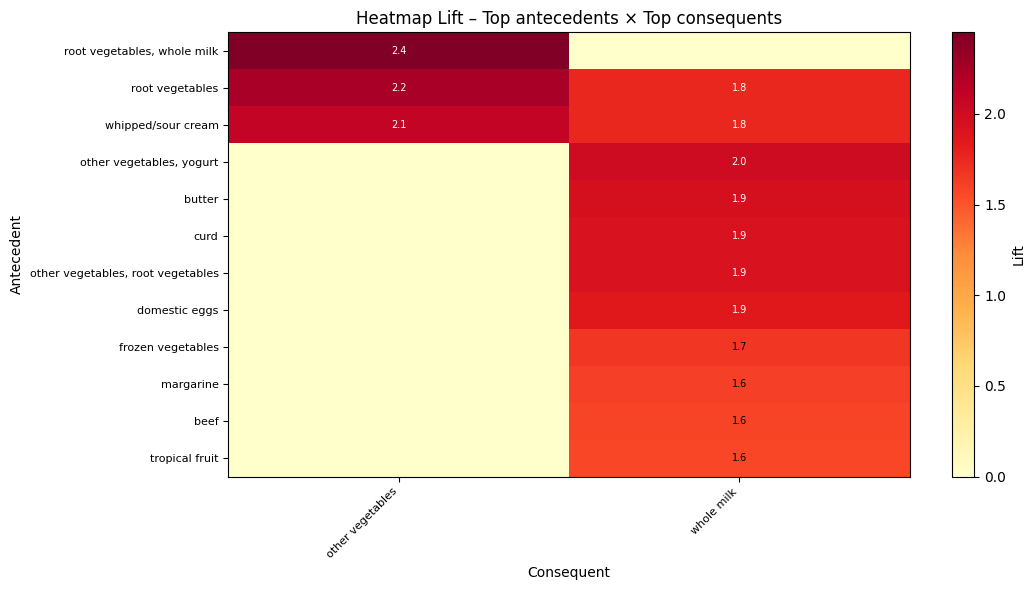

In [57]:
# ── Heatmap lift giữa top antecedents và top consequents ─────────────────────
top_ant = rules_df.groupby("antecedent")["lift"].max().nlargest(12).index.tolist()
top_con = rules_df.groupby("consequent")["lift"].max().nlargest(12).index.tolist()

pivot_data = (
    rules_df[rules_df["antecedent"].isin(top_ant) & rules_df["consequent"].isin(top_con)]
    .pivot_table(index="antecedent", columns="consequent", values="lift", aggfunc="max")
    .reindex(index=top_ant, columns=top_con)
)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(pivot_data.fillna(0).values, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax, label="Lift")
ax.set_xticks(range(len(top_con))); ax.set_xticklabels(top_con, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(top_ant))); ax.set_yticklabels(top_ant, fontsize=8)
for r in range(len(top_ant)):
    for c in range(len(top_con)):
        v = pivot_data.fillna(0).values[r, c]
        if v > 0:
            ax.text(c, r, f"{v:.1f}", ha="center", va="center", fontsize=7,
                    color="black" if v < pivot_data.max().max() * 0.7 else "white")
ax.set_title("Heatmap Lift – Top antecedents × Top consequents")
ax.set_xlabel("Consequent")
ax.set_ylabel("Antecedent")
plt.tight_layout()
save_figure(fig, "mba_lift_heatmap.png")
plt.show()


**Nhận xét:** Heatmap cho thấy các cặp antecedent-consequent có quan hệ mua kèm nổi bật hơn ngẫu nhiên. Những ô có `lift` cao là ứng viên tốt để kiểm tra sâu hơn, nhưng không nên kết luận chỉ từ màu sắc vì heatmap không thể hiện trực tiếp số giao dịch hỗ trợ cho từng luật.

Đã lưu hình: docs\figures\mba_rules_bubble.png


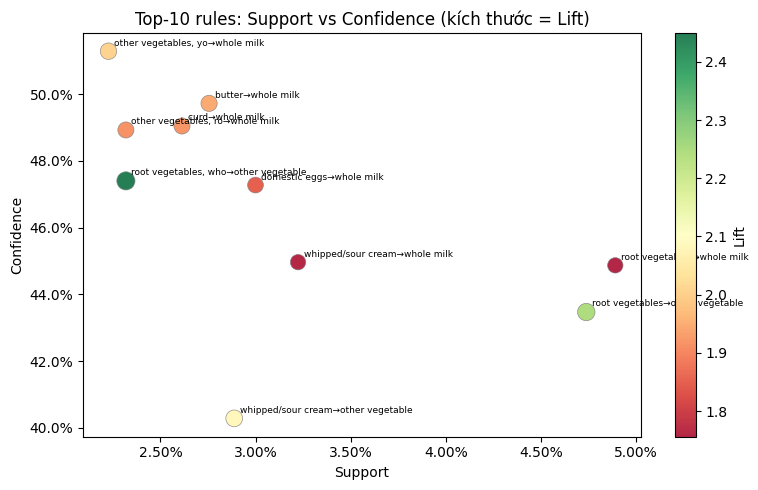

In [58]:
# ── Bubble chart: support vs confidence, kích thước & màu theo lift ──────────
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    top10_rules["support"],
    top10_rules["confidence"],
    c=top10_rules["lift"],
    s=top10_rules["lift"] * 70,
    cmap="RdYlGn",
    alpha=0.85,
    edgecolors="grey",
    linewidths=0.5,
)
plt.colorbar(sc, ax=ax, label="Lift")
for _, row in top10_rules.iterrows():
    ax.annotate(
        f"{row['antecedent'][:20]}→{row['consequent'][:15]}",
        (row["support"], row["confidence"]),
        fontsize=6.5,
        xytext=(4, 4),
        textcoords="offset points",
    )
ax.set_xlabel("Support")
ax.set_ylabel("Confidence")
ax.set_title("Top-10 rules: Support vs Confidence (kích thước = Lift)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
save_figure(fig, "mba_rules_bubble.png")
plt.show()


**Nhận xét:** Bubble chart giúp thấy luật nào vừa có `confidence` tốt vừa có `support` không quá thấp. Các điểm có `lift` cao nhưng nằm quá trái cần được xem xét thận trọng, vì chúng có thể chỉ xuất hiện trong ít giao dịch.

Đã lưu hình: docs\figures\mba_top_rules_lift.png


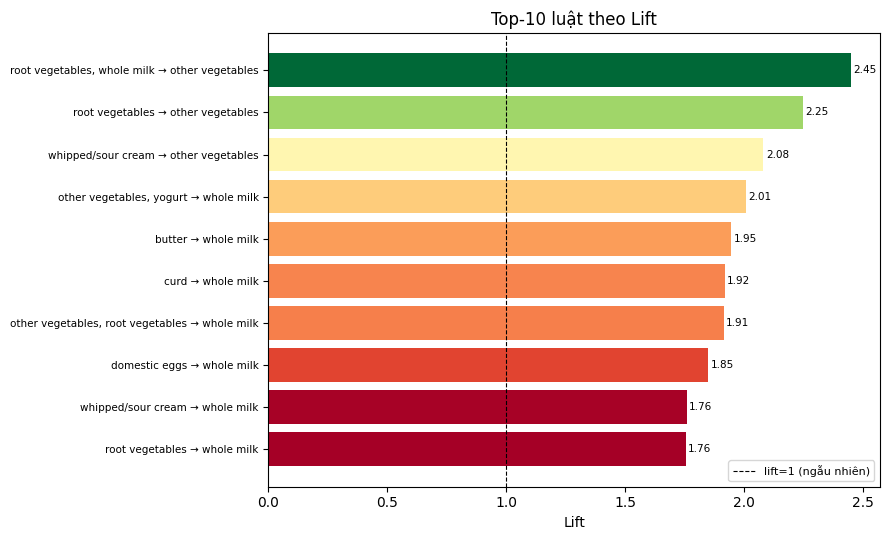

In [59]:
# ── Horizontal bar: so sánh lift của top-10 luật ─────────────────────────────
sorted_rules = top10_rules.sort_values("lift")
bar_labels = [f"{r['antecedent']} → {r['consequent']}" for _, r in sorted_rules.iterrows()]
colors = plt.cm.RdYlGn(
    (sorted_rules["lift"].values - sorted_rules["lift"].min())
    / (sorted_rules["lift"].max() - sorted_rules["lift"].min() + 1e-9)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(range(len(sorted_rules)), sorted_rules["lift"], color=colors)
ax.set_yticks(range(len(sorted_rules)))
ax.set_yticklabels(bar_labels, fontsize=7.5)
ax.set_xlabel("Lift")
ax.set_title("Top-10 luật theo Lift")
ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8, label="lift=1 (ngẫu nhiên)")
ax.legend(fontsize=8)
for bar, val in zip(bars, sorted_rules["lift"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=7.5)

plt.tight_layout()
save_figure(fig, "mba_top_rules_lift.png")
plt.show()


**Nhận xét:** Biểu đồ cột giúp so sánh nhanh độ mạnh tương đối của các luật theo `lift`. Tuy vậy, đây chỉ là bước lọc ban đầu; khi đưa vào hành động kinh doanh cần đối chiếu thêm `support_count`, `confidence`, `leverage` và bối cảnh sản phẩm.

## 12. Diễn giải ý nghĩa kinh doanh

Cách đọc một luật:

```text
antecedent ⇒ consequent
```

nghĩa là: khi khách hàng mua nhóm sản phẩm ở vế trái, họ có xu hướng mua thêm nhóm sản phẩm ở vế phải.

Các gợi ý kinh doanh có thể rút ra:

- Đặt các sản phẩm liên quan gần nhau để tăng khả năng mua kèm.
- Tạo combo khuyến mãi cho các cặp/nhóm sản phẩm có `lift` cao và `support` đủ lớn.
- Gợi ý sản phẩm bổ sung trong hệ thống bán hàng hoặc thương mại điện tử.
- Tối ưu bố trí kệ hàng dựa trên hành vi mua thực tế.

Phần dưới đây chọn các luật tiêu biểu và diễn giải theo hướng hành động, thay vì chỉ liệt kê chỉ số.


In [60]:
def explain_rule(row):
    """Diễn giải luật kết hợp với gợi ý kinh doanh cụ thể theo từng loại."""
    lift_val       = row["lift"]
    confidence_val = row["confidence"]
    support_val    = row["support"]
    leverage_val   = row.get("leverage", float("nan"))
    conviction_val = row.get("conviction", float("nan"))

    # Phân loại sức mạnh luật
    if lift_val >= 3:
        strength = "rất mạnh"
        biz_action = (
            f"→ Gợi ý: tạo combo khuyến mãi '{row['antecedent']} + {row['consequent']}'; "
            "đặt hai nhóm sản phẩm gần nhau trên kệ hoặc trong giỏ gợi ý."
        )
    elif lift_val >= 2:
        strength = "mạnh"
        biz_action = (
            f"→ Gợi ý: thêm '{row['consequent']}' vào danh sách gợi ý khi khách thêm "
            f"'{row['antecedent']}' vào giỏ hàng."
        )
    elif lift_val > 1:
        strength = "tích cực (nhẹ)"
        biz_action = (
            f"→ Gợi ý: cân nhắc email/thông báo đẩy gợi ý '{row['consequent']}' "
            f"cho khách đã mua '{row['antecedent']}'."
        )
    else:
        strength = "không rõ ràng hoặc ngược chiều"
        biz_action = "→ Lưu ý: luật này không đủ mạnh để áp dụng trong chiến lược bán kèm."

    # Đánh giá confidence
    if confidence_val >= 0.7:
        conf_note = "Độ tin cậy cao — luật dự đoán tốt."
    elif confidence_val >= 0.4:
        conf_note = "Độ tin cậy trung bình — phù hợp gợi ý nhẹ."
    else:
        conf_note = "Độ tin cậy thấp — nên kết hợp với tiêu chí khác."

    conviction_str = f"{conviction_val:.2f}" if not math.isinf(conviction_val) and not math.isnan(conviction_val) else "∞"
    leverage_str   = f"{leverage_val:+.4f}"  if not math.isnan(leverage_val)   else "N/A"

    return (
        f"Luật [{row['antecedent']}] ⇒ [{row['consequent']}]\n"
        f"  support={support_val:.3f} ({int(row['support_count'])} giao dịch)  "
        f"confidence={confidence_val:.3f}  lift={lift_val:.3f}  "
        f"leverage={leverage_str}  conviction={conviction_str}\n"
        f"  Quan hệ: {strength}. {conf_note}\n"
        f"  {biz_action}"
    )


for idx, row in top10_rules.iterrows():
    print(f"{idx + 1}. {explain_rule(row)}")
    print()


1. Luật [root vegetables, whole milk] ⇒ [other vegetables]
  support=0.023 (228 giao dịch)  confidence=0.474  lift=2.450  leverage=+0.0137  conviction=1.53
  Quan hệ: mạnh. Độ tin cậy trung bình — phù hợp gợi ý nhẹ.
  → Gợi ý: thêm 'other vegetables' vào danh sách gợi ý khi khách thêm 'root vegetables, whole milk' vào giỏ hàng.

2. Luật [root vegetables] ⇒ [other vegetables]
  support=0.047 (466 giao dịch)  confidence=0.435  lift=2.247  leverage=+0.0263  conviction=1.43
  Quan hệ: mạnh. Độ tin cậy trung bình — phù hợp gợi ý nhẹ.
  → Gợi ý: thêm 'other vegetables' vào danh sách gợi ý khi khách thêm 'root vegetables' vào giỏ hàng.

3. Luật [whipped/sour cream] ⇒ [other vegetables]
  support=0.029 (284 giao dịch)  confidence=0.403  lift=2.082  leverage=+0.0150  conviction=1.35
  Quan hệ: mạnh. Độ tin cậy trung bình — phù hợp gợi ý nhẹ.
  → Gợi ý: thêm 'other vegetables' vào danh sách gợi ý khi khách thêm 'whipped/sour cream' vào giỏ hàng.

4. Luật [other vegetables, yogurt] ⇒ [whole milk]

### Bảng tổng hợp luật tiêu biểu

Bảng này tóm tắt luật, chỉ số chính, ý nghĩa và đề xuất hành động để phần kết quả dễ dùng hơn trong bối cảnh kinh doanh.

In [61]:
def business_meaning(row):
    return (
        f"Khách mua {row['antecedent']} có xu hướng mua {row['consequent']} "
        f"với confidence {row['confidence']:.1%}; lift {row['lift']:.2f} cho thấy quan hệ cao hơn ngẫu nhiên."
    )


def recommended_action(row):
    if row["support"] >= 0.03 and row["confidence"] >= 0.45:
        return "Ưu tiên đặt gần nhau, tạo combo hoặc gợi ý mua kèm trực tiếp."
    if row["lift"] >= 2 and row["support"] >= selected_minsup:
        return "Dùng làm gợi ý mua kèm có điều kiện; kiểm thử bằng khuyến mãi nhỏ."
    return "Theo dõi thêm trước khi triển khai rộng vì độ phổ biến còn hạn chế."

business_summary_df = top10_rules.assign(
    **{
        "luật kết hợp": lambda df: df["antecedent"] + " ⇒ " + df["consequent"],
        "ý nghĩa": lambda df: df.apply(business_meaning, axis=1),
        "đề xuất hành động": lambda df: df.apply(recommended_action, axis=1),
    }
).loc[:, ["luật kết hợp", "support", "support_count", "confidence", "lift", "ý nghĩa", "đề xuất hành động"]]

display(
    business_summary_df.style
    .format({"support": "{:.3f}", "confidence": "{:.3f}", "lift": "{:.3f}"})
    .set_caption("Bảng tổng hợp luật kết hợp tiêu biểu và đề xuất hành động")
)


,luật kết hợp,support,support_count,confidence,lift,ý nghĩa,đề xuất hành động
0,"root vegetables, whole milk ⇒ other vegetables",0.023,228,0.474,2.450,"Khách mua root vegetables, whole milk có xu hướng mua other vegetables với confidence 47.4%; lift 2.45 cho thấy quan hệ cao hơn ngẫu nhiên.",Dùng làm gợi ý mua kèm có điều kiện; kiểm thử bằng khuyến mãi nhỏ.
1,root vegetables ⇒ other vegetables,0.047,466,0.435,2.247,Khách mua root vegetables có xu hướng mua other vegetables với confidence 43.5%; lift 2.25 cho thấy quan hệ cao hơn ngẫu nhiên.,Dùng làm gợi ý mua kèm có điều kiện; kiểm thử bằng khuyến mãi nhỏ.
2,whipped/sour cream ⇒ other vegetables,0.029,284,0.403,2.082,Khách mua whipped/sour cream có xu hướng mua other vegetables với confidence 40.3%; lift 2.08 cho thấy quan hệ cao hơn ngẫu nhiên.,Dùng làm gợi ý mua kèm có điều kiện; kiểm thử bằng khuyến mãi nhỏ.
3,"other vegetables, yogurt ⇒ whole milk",0.022,219,0.513,2.007,"Khách mua other vegetables, yogurt có xu hướng mua whole milk với confidence 51.3%; lift 2.01 cho thấy quan hệ cao hơn ngẫu nhiên.",Dùng làm gợi ý mua kèm có điều kiện; kiểm thử bằng khuyến mãi nhỏ.
4,butter ⇒ whole milk,0.028,271,0.497,1.946,Khách mua butter có xu hướng mua whole milk với confidence 49.7%; lift 1.95 cho thấy quan hệ cao hơn ngẫu nhiên.,Theo dõi thêm trước khi triển khai rộng vì độ phổ biến còn hạn chế.
5,curd ⇒ whole milk,0.026,257,0.490,1.919,Khách mua curd có xu hướng mua whole milk với confidence 49.0%; lift 1.92 cho thấy quan hệ cao hơn ngẫu nhiên.,Theo dõi thêm trước khi triển khai rộng vì độ phổ biến còn hạn chế.
6,"other vegetables, root vegetables ⇒ whole milk",0.023,228,0.489,1.915,"Khách mua other vegetables, root vegetables có xu hướng mua whole milk với confidence 48.9%; lift 1.91 cho thấy quan hệ cao hơn ngẫu nhiên.",Theo dõi thêm trước khi triển khai rộng vì độ phổ biến còn hạn chế.
7,domestic eggs ⇒ whole milk,0.030,295,0.473,1.850,Khách mua domestic eggs có xu hướng mua whole milk với confidence 47.3%; lift 1.85 cho thấy quan hệ cao hơn ngẫu nhiên.,Theo dõi thêm trước khi triển khai rộng vì độ phổ biến còn hạn chế.
8,whipped/sour cream ⇒ whole milk,0.032,317,0.450,1.760,Khách mua whipped/sour cream có xu hướng mua whole milk với confidence 45.0%; lift 1.76 cho thấy quan hệ cao hơn ngẫu nhiên.,Theo dõi thêm trước khi triển khai rộng vì độ phổ biến còn hạn chế.
9,root vegetables ⇒ whole milk,0.049,481,0.449,1.756,Khách mua root vegetables có xu hướng mua whole milk với confidence 44.9%; lift 1.76 cho thấy quan hệ cao hơn ngẫu nhiên.,Theo dõi thêm trước khi triển khai rộng vì độ phổ biến còn hạn chế.


## 13. Nhận xét tổng hợp

Dựa trên top-10 luật theo `lift`, có thể tập trung vào các luật có cả ba đặc điểm:

1. `lift > 1`: quan hệ mua kèm mạnh hơn ngẫu nhiên.
2. `confidence` đủ cao: luật có khả năng dự đoán tốt.
3. `support` không quá thấp: luật xuất hiện trên số lượng giao dịch đủ đáng kể.

Về mặt kinh doanh, các luật như `root vegetables ⇒ other vegetables`, `butter ⇒ whole milk`, `domestic eggs ⇒ whole milk` hoặc các biến thể kết hợp với `yogurt`, `whole milk`, `other vegetables` là các ứng viên dễ diễn giải. Cửa hàng có thể đặt các nhóm hàng này gần nhau, tạo combo theo bữa ăn hoặc thêm gợi ý mua kèm tại quầy thanh toán/website.

Trong thực tế, không nên chỉ chọn luật có `lift` cao nhất nếu `support` quá thấp, vì luật đó có thể chỉ xuất hiện trong rất ít giao dịch. Một luật tốt nên cân bằng giữa `support`, `confidence`, `lift`, đồng thời xem thêm `leverage` và `conviction` để tránh kết luận quá mức.

Với lần chạy hiện tại, notebook ghi rõ thuật toán thực tế được dùng ở cell chọn ngưỡng. Nếu môi trường có Julia và project PrePost hoạt động, kết quả sẽ thể hiện `Project PrePost/optimized qua Julia CLI`; nếu phải dùng fallback, notebook cũng hiển thị rõ tên fallback để tránh nhầm lẫn với PrePost.


## 14. Hạn chế

- Dữ liệu không có thời gian mua hàng, số lượng sản phẩm, giá trị hóa đơn hoặc thông tin khách hàng, nên chưa phân tích được mùa vụ, giá trị đơn hàng hay phân khúc khách.
- Association rules chỉ thể hiện quan hệ đồng xuất hiện trong giỏ hàng, không chứng minh quan hệ nhân quả.
- Một số luật có `lift` cao nhưng `support` thấp nên cần kiểm thử thực tế trước khi triển khai rộng.
- Kết quả phụ thuộc vào ngưỡng `minsup` và `minconf` được chọn; nếu thay đổi mục tiêu kinh doanh, cần thử lại nhiều ngưỡng khác.


## 15. Kết luận

Notebook đã hoàn thành phần ứng dụng thực tế cho bài toán **Market Basket Analysis** với các cải tiến:

- Đọc và tiền xử lý dữ liệu `groceries.txt` thành danh sách transaction.
- **EDA mở rộng**: top item, co-occurrence matrix top-15 items và phân bố kích thước giỏ hàng.
- Lưu toàn bộ biểu đồ chính vào `../docs/figures/` để dùng lại trong báo cáo.
- Khai phá frequent itemsets theo thứ tự ưu tiên: Julia/PrePost của project → **mlxtend (không giới hạn k)** → Apriori thuần Python.
- Hiển thị rõ thuật toán thực tế được sử dụng trong lần chạy, giúp phân biệt PrePost với các fallback.
- Sinh association rules với đầy đủ `support`, `confidence`, `lift`, **`leverage`**, **`conviction`**.
- **Bảng tổng hợp ngưỡng**: hiển thị số luật theo mọi cặp (minsup, minconf) và giải thích lý do chọn ngưỡng cuối cùng.
- Trình bày từng biểu đồ riêng hơn, kèm nhận xét ngay sau biểu đồ.
- Bổ sung **bảng tổng hợp luật tiêu biểu** gồm luật kết hợp, chỉ số, ý nghĩa và đề xuất hành động.
- **Diễn giải kinh doanh** tập trung vào cách áp dụng: đặt sản phẩm gần nhau, tạo combo, gợi ý mua kèm và thử nghiệm khuyến mãi.

Kết quả có thể hỗ trợ cửa hàng ra quyết định thực tế, nhưng khi triển khai cần đánh giá đồng thời nhiều chỉ số thay vì chỉ dựa vào `lift`.
